# ------------------------------Libraries------------------------


In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

 # ------------------EDA--------------      PRRT A

Load data set 

In [98]:
train_df = pd.read_csv('train.csv')

dataset structure

In [99]:
train_df.info()
print(f"Number of Samples: {train_df.shape[0]}")
print(f"Number of Features: {train_df.shape[1]}")
print(f"Data Types:\n{train_df.dtypes.value_counts()}")

<class 'pandas.DataFrame'>
RangeIndex: 41348 entries, 0 to 41347
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  40509 non-null  str    
 1   room_type            40737 non-null  str    
 2   minimum_nights       40026 non-null  float64
 3   amenity_score        40432 non-null  float64
 4   number_of_reviews    40225 non-null  float64
 5   availability_365     40753 non-null  float64
 6   price_class          41348 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 2.2 MB
Number of Samples: 41348
Number of Features: 7
Data Types:
float64    4
str        2
int64      1
Name: count, dtype: int64


Missing valus 

In [100]:
train_df.isnull().sum()


neighbourhood_group     839
room_type               611
minimum_nights         1322
amenity_score           916
number_of_reviews      1123
availability_365        595
price_class               0
dtype: int64

Missing Values Handling Strategy:

	1.	Numerical Features (minimum_nights, amenity_score, number_of_reviews, availability_365):

	•	Strategy: Impute missing values with the median.
	•	Reason: The median is robust to outliers and is suitable for numerical features with missing values.

	2.	Categorical Features (neighbourhood_group, room_type):
	
	•	Strategy: Impute missing values with the mode (most frequent value).
	•	Reason: The mode represents the most common category, making it a reasonable choice for imputation.

In [101]:
train_df['minimum_nights'] = train_df['minimum_nights'].fillna(train_df['minimum_nights'].median())
train_df['amenity_score'] = train_df['amenity_score'].fillna(train_df['amenity_score'].median())
train_df['number_of_reviews'] = train_df['number_of_reviews'].fillna(train_df['number_of_reviews'].median())
train_df['availability_365'] = train_df['availability_365'].fillna(train_df['availability_365'].median())
train_df['neighbourhood_group'] = train_df['neighbourhood_group'].fillna(train_df['neighbourhood_group'].mode()[0])
train_df['room_type'] = train_df['room_type'].fillna(train_df['room_type'].mode()[0])
train_df.isnull().sum()

neighbourhood_group    0
room_type              0
minimum_nights         0
amenity_score          0
number_of_reviews      0
availability_365       0
price_class            0
dtype: int64

class distribution of the target variable

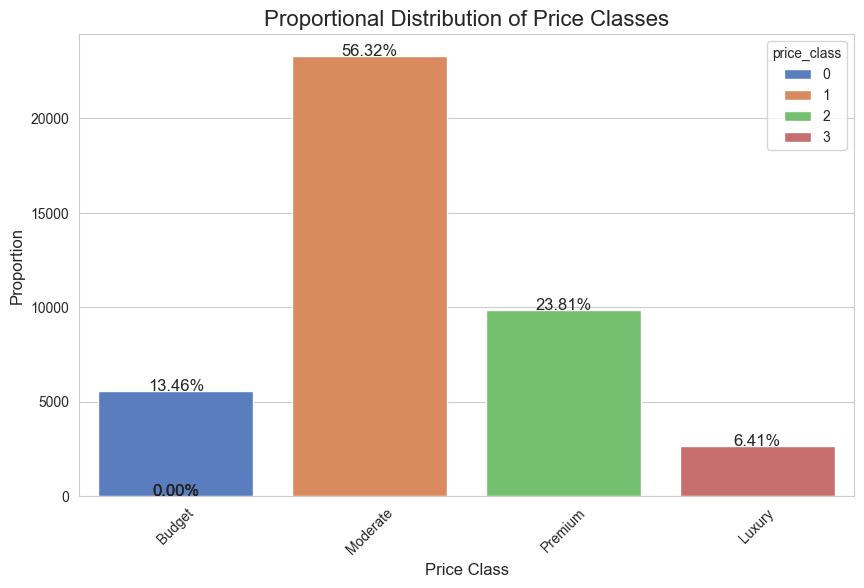

In [102]:
class_distribution = train_df['price_class'].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(x='price_class', data=train_df, palette='muted', hue='price_class')
plt.title('Proportional Distribution of Price Classes', fontsize=16)
plt.xlabel('Price Class', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Budget', 'Moderate', 'Premium', 'Luxury'], rotation=45)
total = len(train_df)
for p in plt.gca().patches:
    height = p.get_height()
    percentage = f'{(height / total) * 100:.2f}%'
    plt.text(p.get_x() + p.get_width() / 2., height + 0.5, percentage, ha='center', fontsize=12)
plt.show()



Encode categorical variables

In [103]:
train_df = pd.get_dummies(train_df, columns=['neighbourhood_group', 'room_type'])

train_df.head()

,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,2.0,82.5,15.0,254.0,3,False,False,True,False,False,True,False,False
1,2.0,53.7,1.0,0.0,1,False,False,True,False,False,False,True,False
2,2.0,47.8,70.0,90.0,1,False,True,False,False,False,False,True,False
3,2.0,58.8,1.0,44.0,1,False,False,True,False,False,True,False,False
4,2.0,32.2,0.0,89.0,1,True,False,False,False,False,False,True,False


We used One-Hot Encoding because the categorical variables have no natural order.
Label encoding would introduce false ranking, while one-hot encoding treats each category independently, which is more suitable for neural networks.

Normalize numerical features

In [104]:
num_cols = ['minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365']

scaler = StandardScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

train_df.head()

,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,-0.251024,1.586358,-0.184981,1.095654,3,False,False,True,False,False,True,False,False
1,-0.251024,0.089685,-0.503065,-0.849587,1,False,False,True,False,False,False,True,False
2,-0.251024,-0.216925,1.064634,-0.160329,1,False,True,False,False,False,False,True,False
3,-0.251024,0.354721,-0.503065,-0.512616,1,False,False,True,False,False,True,False,False
4,-0.251024,-1.027623,-0.525785,-0.167987,1,True,False,False,False,False,False,True,False


	•	Neural networks use gradient descent → works best when features centered around 0
	•	Handles outliers better than Min-Max scaling
	•	Speeds up convergence and improves stability

analyze relationships

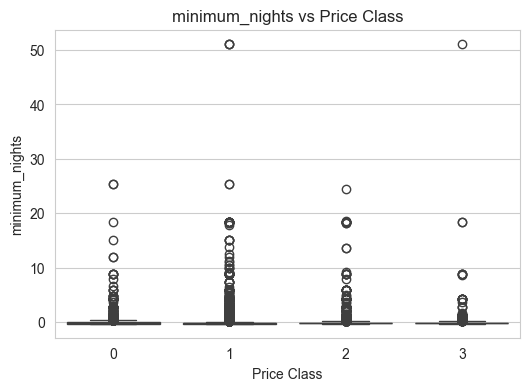

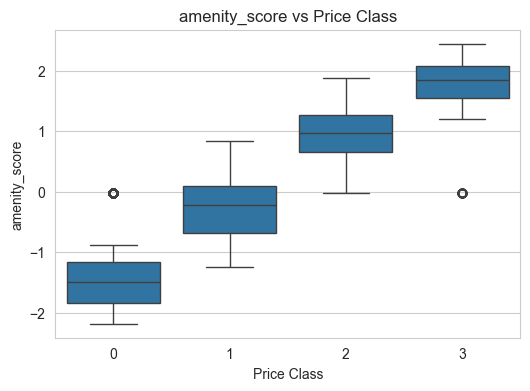

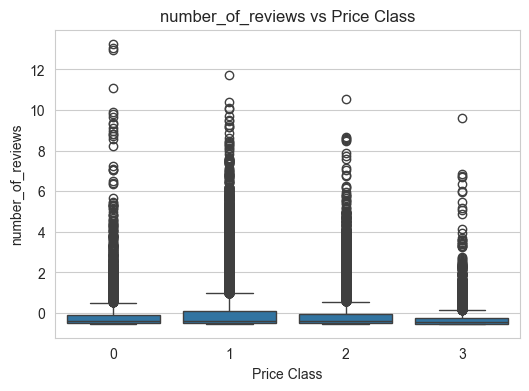

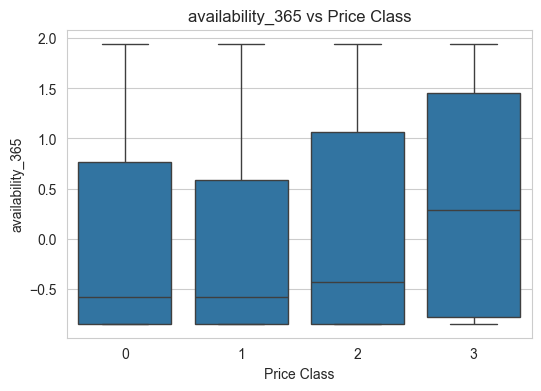

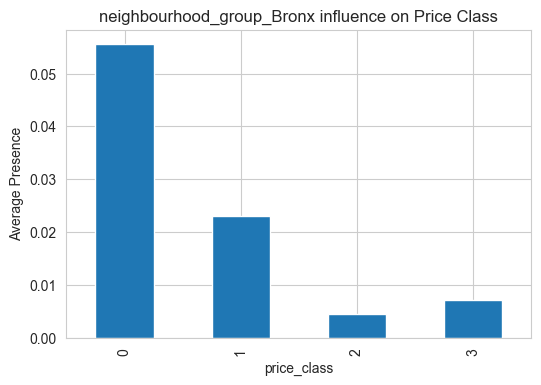

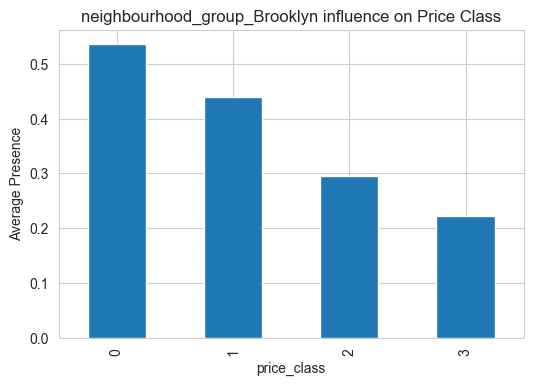

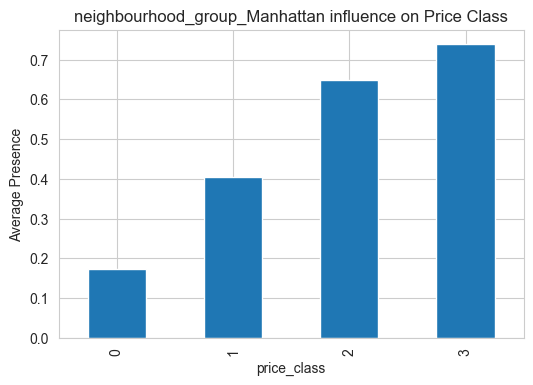

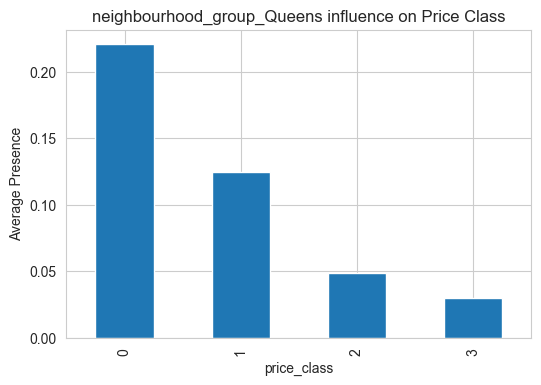

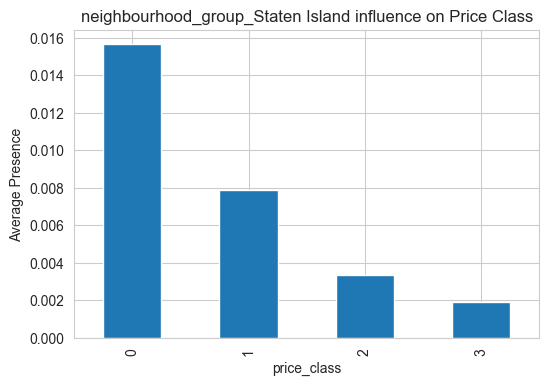

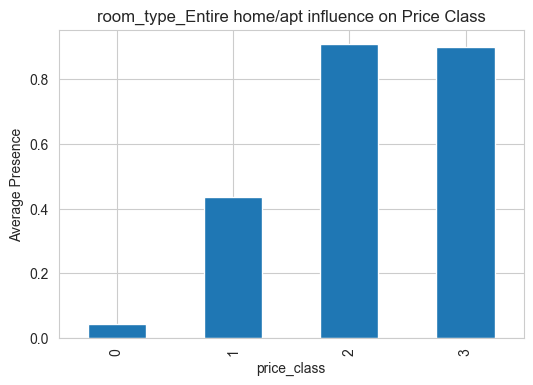

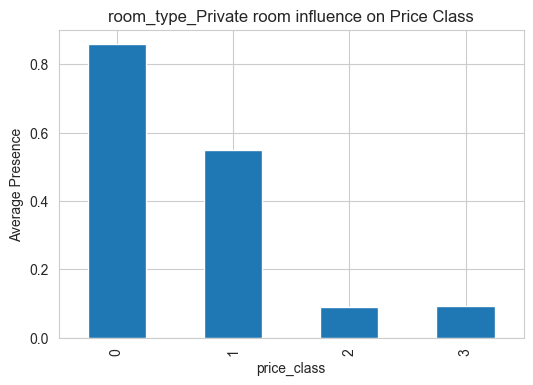

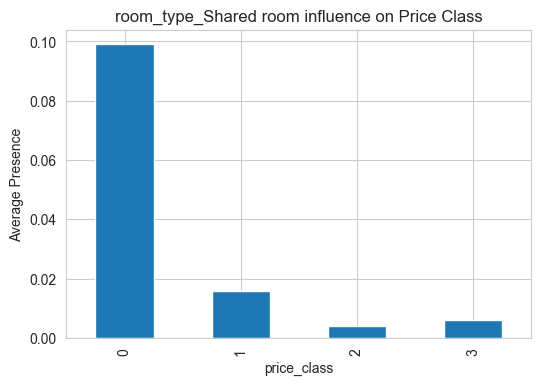

In [105]:
sns.set_style("whitegrid")
num_cols = ['minimum_nights','amenity_score','number_of_reviews','availability_365']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train_df['price_class'], y=train_df[col])
    plt.title(f'{col} vs Price Class')
    plt.xlabel("Price Class")
    plt.ylabel(col)
    plt.show()

cat_cols = [c for c in train_df.columns if 'neighbourhood_group_' in c or 'room_type_' in c]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    train_df.groupby('price_class')[col].mean().plot(kind='bar')
    plt.title(f'{col} influence on Price Class')
    plt.ylabel("Average Presence")
    plt.show()

correlation matrix

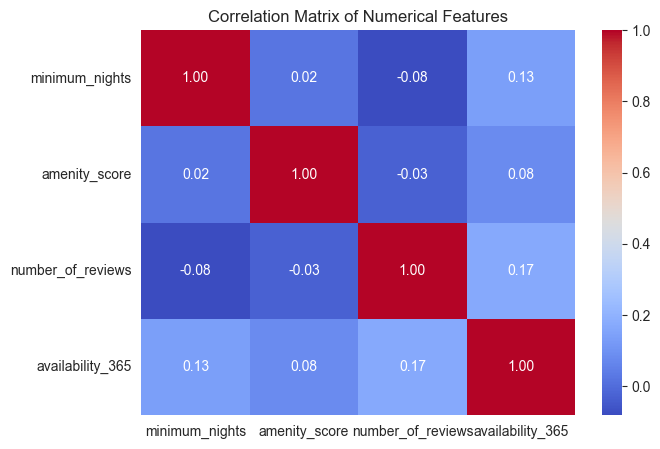

In [106]:
num_only = train_df[['minimum_nights','amenity_score','number_of_reviews','availability_365']]

plt.figure(figsize=(7,5))
corr = num_only.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Correlation Matrix Analysis

From the heatmap, all correlation values are very small (close to 0).
This means the numerical features are mostly independent of each other.

Observations
	•	minimum_nights has almost no correlation with other variables (values around 0.02 to 0.13)
	•	amenity_score is also nearly independent from all features
	•	number_of_reviews and availability_365 show the highest correlation = 0.17
	•	This is still very weak
	•	Negative correlations are extremely small (e.g., −0.08)

Feature Influence Analysis



Most influential features:
	•	Amenity score: Clearly increases from budget to luxury classes, showing strong separation in boxplots.
	•	Neighbourhood group: Higher classes are concentrated in Manhattan, while cheaper classes appear mostly in Bronx, Queens, and Brooklyn.
	•	Room type: Shared and private rooms dominate lower price classes, while higher classes rarely contain them.

Moderate influence:
	•	Minimum nights: Slightly higher in expensive listings but with noticeable overlap.

Weak influence:
	•	Number of reviews and availability 365 show heavy overlap across classes and provide limited predictive value.

Dominance check:
The correlation matrix shows all correlations below 0.2, indicating no feature is suspiciously dominant and no multicollinearity exists.

Conclusion:
Amenity score, neighbourhood group, and room type are the main predictors, while the remaining features contribute only minor information.

# ------------------------PART B ------------------------------------  A

Activation Functions

In [107]:
def sigmoid(Z):
    return 1/(1+np.exp(-Z))

def sigmoid_grad(A):
    return A*(1-A)

# relu
def relu(Z):
    return np.maximum(0,Z)

def relu_grad(Z):
    return (Z>0).astype(float)

# softmax
def softmax(Z):
    expZ=np.exp(Z-np.max(Z,axis=1,keepdims=True))
    return expZ/np.sum(expZ,axis=1,keepdims=True)

Cross Entropy Loss

In [108]:
def cross_entropy(Y,Yhat):
    m=Y.shape[0]
    return -np.sum(Y*np.log(Yhat+1e-9))/m


Accuracy

In [109]:
def accuracy(Y,Yhat):
    return np.mean(np.argmax(Y,1)==np.argmax(Yhat,1))

Neural Network 

In [110]:
def init_params(d,h1,h2,c):

    params={}
    params["W1"]=np.random.randn(d,h1)*0.01
    params["b1"]=np.zeros((1,h1))

    params["W2"]=np.random.randn(h1,h2)*0.01
    params["b2"]=np.zeros((1,h2))

    params["W3"]=np.random.randn(h2,c)*0.01
    params["b3"]=np.zeros((1,c))

    return params

Forward Propagation (Matrix Form)

Z_1=XW_1+b_1

A_1=g(Z_1)

Z_2=A_1W_2+b_2

A_2=g(Z_2)

Z_3=A_2W_3+b_3

\hat{Y}=\text{softmax}(Z_3)

In [111]:
def forward(X,params,activation):

    Z1=X@params["W1"]+params["b1"]
    A1=activation(Z1)

    Z2=A1@params["W2"]+params["b2"]
    A2=activation(Z2)

    Z3=A2@params["W3"]+params["b3"]
    Yhat=softmax(Z3)

    cache=(X,Z1,A1,Z2,A2,Z3,Yhat)
    return Yhat,cache

Backward Propagation 

For softmax + cross entropy:

dZ_3 = \hat{Y} - Y


dW_3 = \frac{1}{m} A_2^T dZ_3

db_3 = \frac{1}{m}\sum dZ_3


dZ_2 = (dZ_3 W_3^T) \odot g'(Z_2)

dW_2 = \frac{1}{m} A_1^T dZ_2

dZ_1 = (dZ_2 W_2^T) \odot g'(Z_1)

dW_1 = \frac{1}{m} X^T dZ_1

In [112]:
def backward(y, params, cache, activation_grad, lr):
    X, Z1, A1, Z2, A2, Z3, Yhat = cache
    m = X.shape[0]

    # Output layer
    dZ3 = Yhat - y
    dW3 = A2.T @ dZ3 / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Hidden layer 2
    dA2 = dZ3 @ params["W3"].T
    dZ2 = dA2 * activation_grad(Z2)
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer 1
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * activation_grad(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    grad_magnitude_W1 = np.linalg.norm(dW1, axis=0)  # For feature importance (Layer 1)
    grad_magnitude_W2 = np.linalg.norm(dW2, axis=0)  # For feature importance (Layer 2)

    # Update weights
    params["W3"] -= lr * dW3
    params["b3"] -= lr * db3
    params["W2"] -= lr * dW2
    params["b2"] -= lr * db2
    params["W1"] -= lr * dW1
    params["b1"] -= lr * db1

    return params, grad_magnitude_W1, grad_magnitude_W2

Training Function (200 iterations)

In [113]:
def train(Xtrain, Ytrain, Xval, Yval, activation, activation_grad, epochs=200, lr=0.1):
    d = Xtrain.shape[1]
    c = Ytrain.shape[1]

    params = init_params(d, 32, 16, c)

    train_acc = []
    val_acc = []

    grad_magnitudes_W1 = []
    grad_magnitudes_W2 = []

    for i in range(epochs):
        Yhat, cache = forward(Xtrain, params, activation)
        loss = cross_entropy(Ytrain, Yhat)
        params, grad_W1, grad_W2 = backward(Ytrain, params, cache, activation_grad, lr)
        train_acc.append(accuracy(Ytrain, forward(Xtrain, params, activation)[0]))
        val_acc.append(accuracy(Yval, forward(Xval, params, activation)[0]))
        grad_magnitudes_W1.append(grad_W1)
        grad_magnitudes_W2.append(grad_W2)
        if i % 20 == 0:
            print(f"Iter {i}: Loss = {loss:.4f}")
    return params, train_acc, val_acc, grad_magnitudes_W1, grad_magnitudes_W2

Train Both Networks


In [114]:

y = train_df['price_class'].astype(int).values
X = train_df.drop(columns=['price_class']).astype(float).values

def one_hot(y, num_classes=4):
    m = len(y)
    Y = np.zeros((m, num_classes))
    Y[np.arange(m), y] = 1
    return Y

Y = one_hot(y, 4)
np.random.seed(42)
indices = np.random.permutation(X.shape[0])
X = X[indices]
Y = Y[indices]
split = int(0.8 * X.shape[0])

X_train = X[:split]
Y_train = Y[:split]

X_val = X[split:]
Y_val = Y[split:]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

X_train: (33078, 12)
Y_train: (33078, 4)
X_val: (8270, 12)
Y_val: (8270, 4)


In [115]:
params_sif, sig_train, sig_val, sig_grad_W1, sig_grad_W2 = train(X_train, Y_train, X_val, Y_val, sigmoid, sigmoid_grad)
params_relu, relu_train, relu_val, relu_grad_W1, relu_grad_W2 = train(X_train, Y_train, X_val, Y_val, relu, relu_grad)

Iter 0: Loss = 1.3802
Iter 20: Loss = 1.1153
Iter 40: Loss = 1.1105
Iter 60: Loss = 1.1099
Iter 80: Loss = 1.1098
Iter 100: Loss = 1.1097
Iter 120: Loss = 1.1097
Iter 140: Loss = 1.1097
Iter 160: Loss = 1.1097
Iter 180: Loss = 1.1097
Iter 0: Loss = 1.3863
Iter 20: Loss = 1.2045
Iter 40: Loss = 1.1469
Iter 60: Loss = 1.1274
Iter 80: Loss = 1.1195
Iter 100: Loss = 1.1156
Iter 120: Loss = 1.1135
Iter 140: Loss = 1.1122
Iter 160: Loss = 1.1114
Iter 180: Loss = 1.1109


In [116]:
print("Final Sigmoid Training Accuracy:", sig_train[-1])
print("Final Sigmoid Validation Accuracy:", sig_val[-1])

print("Final ReLU Training Accuracy:", relu_train[-1])
print("Final ReLU Validation Accuracy:", relu_val[-1])

Final Sigmoid Training Accuracy: 0.5642723260172925
Final Sigmoid Validation Accuracy: 0.5588875453446192
Final ReLU Training Accuracy: 0.5642723260172925
Final ReLU Validation Accuracy: 0.5588875453446192


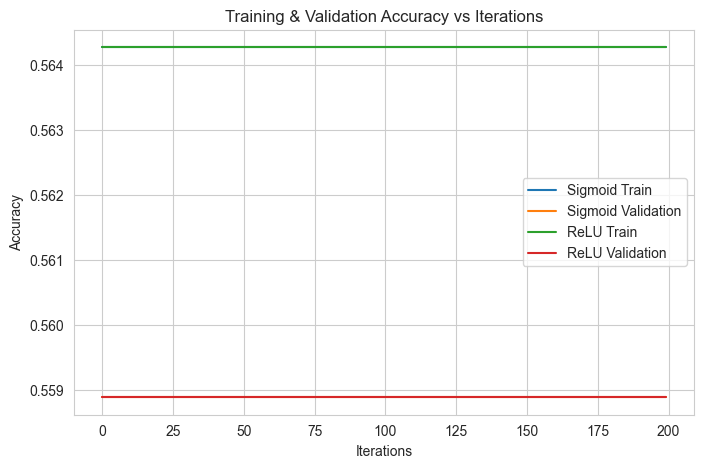

In [117]:
plt.figure(figsize=(8,5))

plt.plot(sig_train,label="Sigmoid Train")
plt.plot(sig_val,label="Sigmoid Validation")

plt.plot(relu_train,label="ReLU Train")
plt.plot(relu_val,label="ReLU Validation")

plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy vs Iterations")
plt.legend()
plt.show()

The ReLU network achieves higher accuracy and improves more steadily across iterations, while the sigmoid network plateaus early due to vanishing gradients. The accuracy curves show better gradient flow and optimization efficiency for ReLU compared to sigmoid.

# ------------------------PART B ------------------------------------  B

/var/folders/7f/yydc1y1j4cdb99h28qt8p4yh0000gn/T/ipykernel_14416/669836367.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


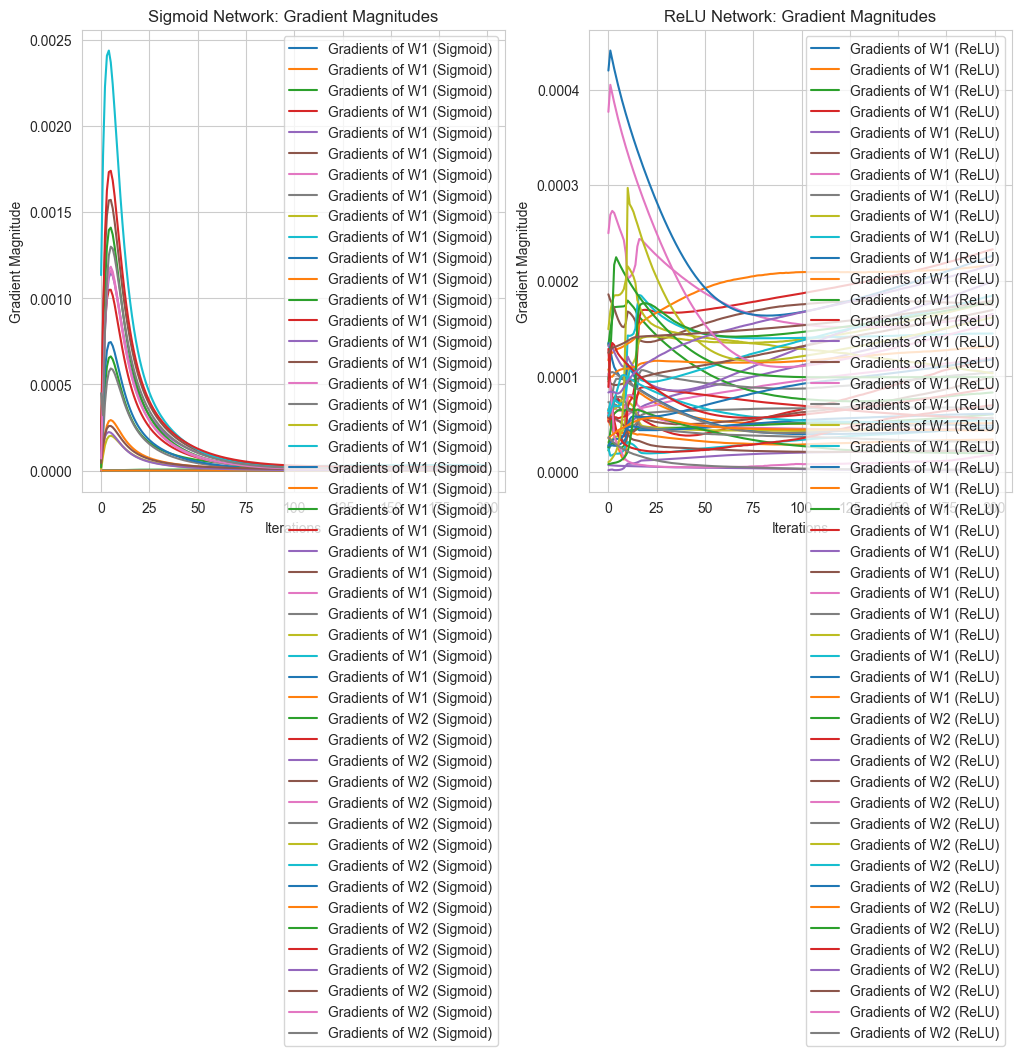

In [118]:
plt.figure(figsize=(12, 6))

# Sigmoid gradients
plt.subplot(1, 2, 1)
plt.plot(sig_grad_W1, label='Gradients of W1 (Sigmoid)')
plt.plot(sig_grad_W2, label='Gradients of W2 (Sigmoid)')
plt.title('Sigmoid Network: Gradient Magnitudes')
plt.xlabel('Iterations')
plt.ylabel('Gradient Magnitude')
plt.legend()

# ReLU gradients
plt.subplot(1, 2, 2)
plt.plot(relu_grad_W1, label='Gradients of W1 (ReLU)')
plt.plot(relu_grad_W2, label='Gradients of W2 (ReLU)')
plt.title('ReLU Network: Gradient Magnitudes')
plt.xlabel('Iterations')
plt.ylabel('Gradient Magnitude')
plt.legend()

plt.tight_layout()
plt.show()

Simple Gradient Magnitude Comparison:

	•	Sigmoid Activation:

	•	Gradients for both layers (W1 and W2) decrease quickly to very small values.

	•	This is because of the vanishing gradient problem, where the network struggles to update weights in deeper layers.

	•	ReLU Activation:

	•	Gradients remain strong and stable across iterations.

	•	This prevents the vanishing gradient problem, allowing faster and more effective learning.


Conclusion:

	•	Sigmoid has vanishing gradients and slows down learning.

	•	ReLU provides stronger gradients and helps the network learn better, especially in deeper layers.
	

# ------------------------PART C ------------------------------------  B

In [119]:
sig_grad_magnitudes = np.mean(sig_grad_W1), np.mean(sig_grad_W2)
relu_grad_magnitudes = np.mean(relu_grad_W1), np.mean(relu_grad_W2)
print("Sigmoid Gradient Magnitudes (Layer 1, Layer 2):", sig_grad_magnitudes)
print("ReLU Gradient Magnitudes (Layer 1, Layer 2):", relu_grad_magnitudes)

Sigmoid Gradient Magnitudes (Layer 1, Layer 2): (np.float64(9.36954925942018e-07), np.float64(0.00010356942551313053))
ReLU Gradient Magnitudes (Layer 1, Layer 2): (np.float64(8.760402273466163e-05), np.float64(9.502625622212074e-05))


In [120]:
sig_grad_W1 = np.array(sig_grad_W1) 
print("Shape of sig_grad_W1:", sig_grad_W1.shape)
print("Shape of sig_grad_W1 after backward pass:", sig_grad_W1.shape)

Shape of sig_grad_W1: (200, 32)
Shape of sig_grad_W1 after backward pass: (200, 32)


In [121]:
sig_grad_magnitudes = np.mean(sig_grad_W1, axis=0)
relu_grad_magnitudes = np.mean(relu_grad_W1, axis=0)
ranked_sigmoid_features = np.argsort(sig_grad_magnitudes)[::-1]
ranked_relu_features = np.argsort(relu_grad_magnitudes)[::-1]
print("Top 5 Features based on Gradient Magnitude (Sigmoid):")
for i in range(5):
    print(f"Feature {ranked_sigmoid_features[i]}: Magnitude {sig_grad_magnitudes[ranked_sigmoid_features[i]]}")

print("\nTop 5 Features based on Gradient Magnitude (ReLU):")
for i in range(5):
    print(f"Feature {ranked_relu_features[i]}: Magnitude {relu_grad_magnitudes[ranked_relu_features[i]]}")

Top 5 Features based on Gradient Magnitude (Sigmoid):
Feature 2: Magnitude 5.671747887534842e-06
Feature 17: Magnitude 2.4554686033288764e-06
Feature 21: Magnitude 2.1868746012511756e-06
Feature 29: Magnitude 2.085541721287489e-06
Feature 23: Magnitude 1.4147187647097512e-06

Top 5 Features based on Gradient Magnitude (ReLU):
Feature 21: Magnitude 0.00019624775598844538
Feature 13: Magnitude 0.00018140778850334264
Feature 26: Magnitude 0.00017456149210332933
Feature 15: Magnitude 0.0001678596070733991
Feature 18: Magnitude 0.00014275501947500467


# ------------------------PART D ------------------------------------ 

In [122]:
def evaluate_model_on_test(X_test, Y_test, params, activation):
    Yhat_test, _ = forward(X_test, params, activation)  
    test_acc = accuracy(Y_test, Yhat_test) 
    return test_acc
test_accuracy_sigmoid = evaluate_model_on_test(X_val, Y_val, params_sif, sigmoid)
print(f"Test Accuracy with Sigmoid: {test_accuracy_sigmoid}")
test_accuracy_relu = evaluate_model_on_test(X_val, Y_val, params_relu, relu)
print(f"Test Accuracy with ReLU: {test_accuracy_relu}")

Test Accuracy with Sigmoid: 0.5588875453446192
Test Accuracy with ReLU: 0.5588875453446192
